In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments'), # Added payments.csv for specific handling
    ('order_items.csv','order_items')
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='2002',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'C:/Users/khush/Desktop/MYSQL PROJECTS/End-to-End E-commerce Data Analysis/Dataset'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing orders.csv
NaN values before replacement:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Processing sellers.csv
NaN values before replacement:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Processing products.csv
NaN values before replacement:
product_id                      0
product category              610
product_name_length           610
product_description_length    610
product_photos_qty            610
prod

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db = mysql.connector.connect(host = "localhost",
                             username = "root",
                             password = "2002",
                             database = "ecommerce")

cur = db.cursor()


In [ ]:
# List all unique cities where customers are located. 

In [21]:
query = """SELECT DISTINCT customer_city FROM customers"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data)
df.head()

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


# Count the number of orders placed in 2017. 

In [11]:
query = """SELECT 
    COUNT(order_id) AS no_of_order_placed
FROM
    orders
WHERE
    YEAR(order_purchase_timestamp) = '2017'"""

cur.execute(query)

data = cur.fetchall()

"Total order placed in 2017 are", data[0][0]

('Total order placed in 2017 are', 45101)

# Find the total sales per category.

In [13]:
query = """SELECT 
    upper(products.product_category) AS category,
    ROUND(SUM(payments.payment_value), 2) AS sales
FROM
    products
        JOIN
    order_items ON order_items.product_id = products.product_id
        JOIN
    payments ON payments.order_id = order_items.order_id
GROUP BY products.product_category;"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["category","sales"])
df

,category,sales
0,PERFUMERY,506738.66
1,FURNITURE DECORATION,1430176.39
2,TELEPHONY,486882.05
3,FASHION BAGS AND ACCESSORIES,218158.28
4,BED TABLE BATH,1712553.67
...,...,...
69,CDS MUSIC DVDS,1199.43
70,LA CUISINE,2913.53
71,FASHION CHILDREN'S CLOTHING,785.67
72,PC GAMER,2174.43


# Calculate the percentage of orders that were paid in installments. 

In [14]:
query = """SELECT 
    (SUM(CASE
        WHEN payment_installments >=1 THEN 1
        ELSE 0
    END)) / COUNT(*) * 100 AS order_purchase_in_installment
FROM
    payments;"""

cur.execute(query)

data = cur.fetchall()
"The percentage of orders that were paid in installments is",data[0][0]

('The percentage of orders that were paid in installments is',
 Decimal('99.9981'))

# Count the number of customers from each state.

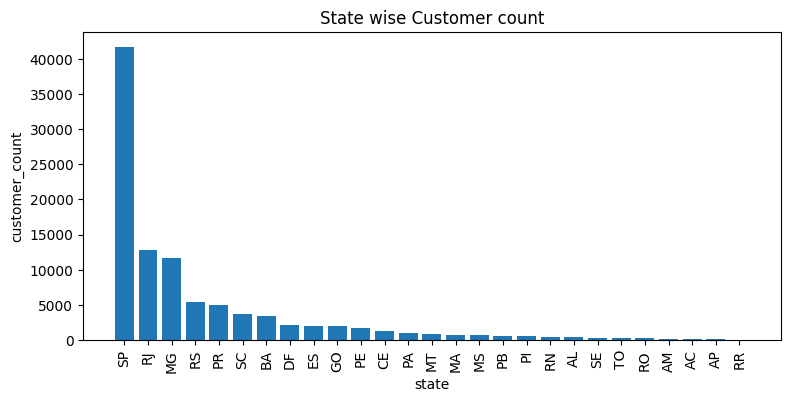

In [29]:
query = """SELECT 
    customer_state,
    COUNT(customer_id)
FROM
    customers
GROUP BY customer_state"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["state","customer_count"])
df = df.sort_values(by = "customer_count", ascending = False)

plt.figure(figsize = (9,4))
plt.bar(df["state"],df["customer_count"])
plt.xticks(rotation = 90)
plt.xlabel("state")
plt.ylabel("customer_count")
plt.title("State wise Customer count")
plt.show()

# Calculate the number of orders per month in 2018. 

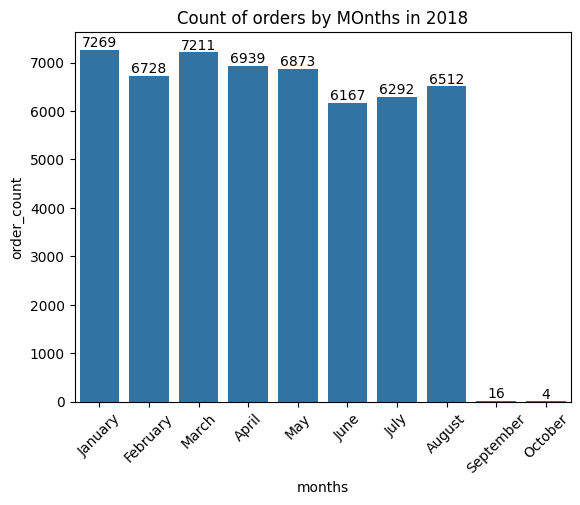

In [30]:
query = """SELECT 
    MONTHNAME(order_purchase_timestamp),
    COUNT(order_id)
FROM
    orders
WHERE
    YEAR(order_purchase_timestamp) = '2018'
GROUP BY MONTHNAME(order_purchase_timestamp)"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["months","order_count"])
o = ["January","February","March","April","May","June","July","August","September","October"]

ax = sns.barplot(x = df["months"], y = df["order_count"], data = df,order = o)
plt.xticks(rotation = 45)
ax.bar_label(ax.containers[0])
plt.title("Count of orders by MOnths in 2018")
plt.show()

# Find the average number of products per order, grouped by customer city. 

In [36]:
query = """WITH count_per_order AS 
(SELECT 
	orders.order_id, orders.customer_id, 
    COUNT(order_items.order_id) AS oc
FROM 
	orders 
    JOIN 
    order_items
ON order_items.order_id=orders.order_id
GROUP BY orders.order_id, orders.customer_id)

SELECT 
    customers.customer_city, ROUND(AVG(count_per_order.oc), 2) AS average_orders
FROM
    customers
        JOIN
    count_per_order ON count_per_order.customer_id = customers.customer_id
GROUP BY customers.customer_city
ORDER BY average_orders DESC;"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["customer_city","average_orders/orders"])
df.head(10)

,customer_city,average_orders/orders
0,padre carvalho,7.00
1,celso ramos,6.50
2,candido godoi,6.00
3,datas,6.00
4,matias olimpio,5.00
5,morro de sao paulo,4.00
6,curralinho,4.00
7,teixeira soares,4.00
8,cidelandia,4.00
9,picarra,4.00


# Calculate the percentage of total revenue contributed by each product category.


In [40]:
query = """SELECT 
    UPPER(products.product_category) AS category,
    ROUND(SUM(payments.payment_value),2) as revenue,
    ROUND((SUM(payments.payment_value) / (SELECT 
                    SUM(payment_value)
                FROM
                    payments)) * 100,
            2) AS revenue_contribution_percentage
FROM
    order_items
        JOIN
    products ON products.product_id = order_items.product_id
        JOIN
    payments ON payments.order_id = order_items.order_id
GROUP BY category
ORDER BY revenue_contribution_percentage DESC"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["category","revenue","percentage_contribution"])
df.head(5)

,category,revenue,percentage_contribution
0,BED TABLE BATH,1712553.67,10.70
1,HEALTH BEAUTY,1657373.12,10.35
2,COMPUTER ACCESSORIES,1585330.45,9.90
3,FURNITURE DECORATION,1430176.39,8.93
4,WATCHES PRESENT,1429216.68,8.93


# Identify the correlation between product price and the number of times a product has been purchased. 

In [45]:
import numpy as np
query = """SELECT 
    products.product_category,
    COUNT(order_items.product_id),
    ROUND(AVG(order_items.price), 2)
FROM
    products
        JOIN
    order_items ON order_items.product_id = products.product_id
GROUP BY products.product_category"""

cur.execute(query)
data=cur.fetchall()
df = pd.DataFrame(data, columns = ["category","order count","price"])

arr1 = df["order count"]
arr2 = df["price"]

a = np.corrcoef(arr1,arr2)
print("Correlation between product price and the number of times a product has been purchased is", a[0][1])

Correlation between product price and the number of times a product has been purchased is -0.10631514167157562


# Calculate the total revenue generated by each seller, and rank them by revenue. 


<function matplotlib.pyplot.show(close=None, block=None)>

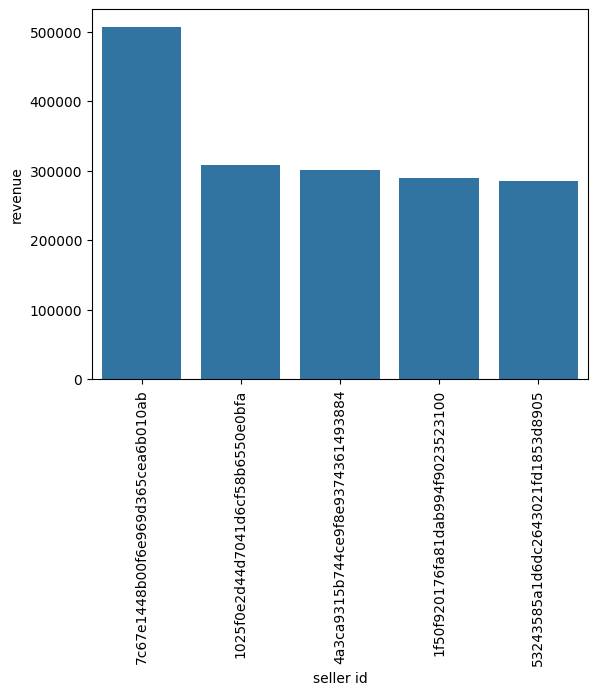

In [50]:
query = """SELECT *, RANK() OVER(order by revenue DESC) AS rn FROM
(SELECT 
    order_items.seller_id,
    ROUND(SUM(payments.payment_value), 2) AS revenue
FROM
    payments
        JOIN
    order_items ON order_items.order_id = payments.order_id
GROUP BY order_items.seller_id) AS a"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["seller id","revenue","rank"])
df = df.head()
sns.barplot(x = "seller id", y = "revenue", data = df)
plt.xticks(rotation = 90)
plt.show

# Calculate the moving average of order values for each customer over their order history.

In [59]:
query = """SELECT customer_id, order_purchase_timestamp, payment, 
        AVG(payment) OVER(PARTITION BY customer_id ORDER BY order_purchase_timestamp 
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) AS moving_avg 
FROM
(SELECT orders.customer_id, orders.order_purchase_timestamp, payments.payment_value AS payment
FROM payments 
JOIN orders ON orders.order_id=payments.order_id) AS a"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["customer id","order time","payment","moving_average"])
df

,customer id,order time,payment,moving_average
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,0.64,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000


# Calculate the cumulative sales per month for each year.

In [61]:
query = """SELECT years, months, revenue, 
ROUND(SUM(revenue) OVER (ORDER BY years, months),2) AS cumulative_revenue 
FROM
(SELECT 
    YEAR(orders.order_purchase_timestamp) AS years,
    MONTH(orders.order_purchase_timestamp) AS months,
    ROUND(SUM(payments.payment_value),2) AS revenue
FROM
    payments
        JOIN
    orders ON orders.order_id = payments.order_id
GROUP BY years , months
ORDER BY years ASC , months ASC) AS a"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years","months","revenue","cumulative revenue"])
df

,years,months,revenue,cumulative revenue
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,197850.38
4,2017,2,291908.01,489758.39
5,2017,3,449863.60,939621.99
6,2017,4,417788.03,1357410.02
7,2017,5,592918.82,1950328.84
8,2017,6,511276.38,2461605.22
9,2017,7,592382.92,3053988.14


# Calculate the year-over-year growth rate of total sales.

In [65]:
query = """WITH a AS
(SELECT 
    YEAR(orders.order_purchase_timestamp) AS years,
    ROUND(SUM(payments.payment_value),2) AS revenue
FROM
    payments
        JOIN
    orders ON orders.order_id = payments.order_id
GROUP BY years
ORDER BY years)

SELECT years, ((revenue - LAG(revenue,1) OVER(ORDER BY years))/
LAG(revenue,1) OVER(ORDER BY years)) * 100  FROM a"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["year","growth rate %"])
df

,year,growth rate %
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


# Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [67]:
query = """WITH a AS (SELECT 
    customers.customer_id, MIN(orders.order_purchase_timestamp) AS first_order
FROM
    customers
        JOIN
    orders ON orders.customer_id = customers.customer_id
GROUP BY customers.customer_id),
b AS
(SELECT a.customer_id, COUNT(DISTINCT orders.order_purchase_timestamp) AS next_order
FROM a JOIN orders ON orders.customer_id=a.customer_id
AND orders.order_purchase_timestamp > first_order
AND orders.order_purchase_timestamp < date_add(first_order, INTERVAL 6 MONTH)
GROUP BY a.customer_id)
SELECT 100 * (COUNT(DISTINCT a.customer_id)/ COUNT(DISTINCT b.customer_id))
FROM a LEFT JOIN b ON b.customer_id=a.customer_id"""

cur.execute(query)
data = cur.fetchall()
data
#No customer make another purchase

[(None,)]

# Identify the top 3 customers who spent the most money in each year.

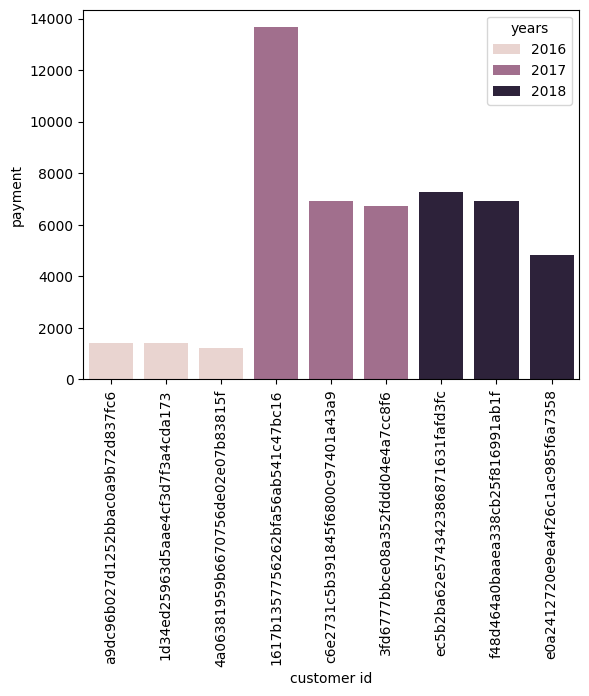

In [74]:
query = """SELECT * FROM
(SELECT 
    YEAR(orders.order_purchase_timestamp) AS year,
    orders.customer_id,
    SUM(payments.payment_value) AS payment,
    DENSE_RANK() OVER(PARTITION BY YEAR(orders.order_purchase_timestamp) ORDER BY SUM(payments.payment_value) DESC) AS rn
FROM
    orders
        JOIN
    payments ON payments.order_id = orders.order_id
GROUP BY YEAR(orders.order_purchase_timestamp), orders.customer_id) AS a
WHERE rn<=3"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years","customer id","payment","rank"])
sns.barplot(x = "customer id" , y = "payment" , data = df , hue = "years")
plt.xticks(rotation = 90)
plt.show()